# Minimization of one variable and many variable functions


In [ ]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## One variable functions

### 1.
$
f_1(x) = {x^6 \over 6} - x^3 + 2x
$

There was used two methods: conjugate gradient (CG) and bounded one-variable method. In CG method was indicated initial guess, equal to $ -1 $ (since in graph minimum point seems to be close to this point). This optimization returned point $ (-0.76, -1.05) $, which is global minimum. In bounded method were indicated bounds $ [0.75; 2] $ (second minimum seems to be in this interval). This optimization returned point $ (1.12, 1.16) $, which is a local minimum.

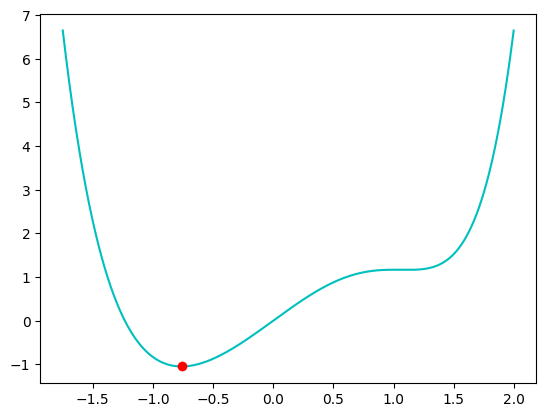

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: -1.0489222720185722
       x: [-7.622e-01]
     nit: 1
     jac: [ 3.278e-07]
    nfev: 15
    njev: 7

 message: Solution found.
 success: True
  status: 0
     fun: 1.164042128078443
       x: 1.1207437498569006
     nit: 23
    nfev: 23


In [ ]:
def f1_1(x):
    return (x**6 / 6) - (x**3) + (2 * x)

x1 = np.arange(-1.75, 2, 0.001)
result1_1_1 = optimize.minimize(f1_1, x0=-1, method='CG')
result1_1_2 = optimize.minimize_scalar(f1_1, method='bounded', bounds=(1, 10))

plt.plot(x1, f1_1(x1), 'c')

plt.plot(result1_1_1.x, result1_1_1.fun, "or")
#plt.plot(result1_1_2.x, result1_1_2.fun, "om")
plt.show()

print(result1_1_1)
print()
print(result1_1_2)

### 2.
$
f_2(x) = x + {1 \over {e^{x-1} - 1}}
$

This function is considered in two intervals - $ (-\infty; 1) $ and $ (1; +\infty) $. In the first interval there is neither global nor local minimum, this function is infinitely decreasing. In the second interval the only global minimum is $ (1.96, 2.58) $. It was found using CG method by setting the initial value to $ 2 $ (the point was selected graphically).

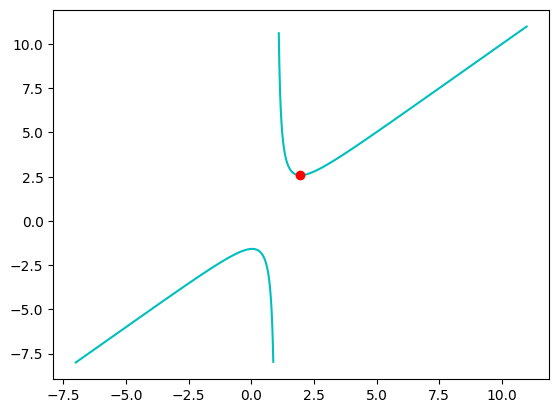

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 2.5804576388691096
       x: [ 1.962e+00]
     nit: 2
     jac: [ 2.086e-07]
    nfev: 10
    njev: 5


In [ ]:
def f1_2(x):
    return x + (1/(np.exp(x-1) - 1))

x2_1 = np.arange(-7, 0.885, 0.01)
x2_2 = np.arange(1.1, 11, 0.01)

result1_2 = optimize.minimize(f1_2, x0=2, method='CG')

plt.plot(x2_1, f1_2(x2_1), 'c')
plt.plot(x2_2, f1_2(x2_2), 'c')

plt.plot(result1_2.x, result1_2.fun, "or")
plt.show()

print(result1_2)

### 3.
$
f_3(x) = x - sin(x)
$

This function's minimums can be easily found mathematically:

$ f_3'(x) = 1 - cos(x) $

$ 1 - cos(x) = 0 $

$ cos(x) = 1 $

$ \underline{x = 2 \pi n, n \in \mathbb{Z}} $

$ f_3''(x) = sin(x) $

$ \underline{sin(2 \pi n) = 0, n \in \mathbb{Z}} $


Therefore, the function has infinite number of weak local minimums, but no global (the graph shows the same). Three of this points were found. For the first one was used bounded scalar method with bounds $[-6.5;-5]$ (graphically selected), the result is $(-6.5, -6.28)$. This method doesn't work properly with this function since it always indicates lower bound as minimum. However, the function value is pretty close to minimum (because the chosen lower bound is close to the real number). Two other points were found with CG method with initial values $ 0 $ and $ 2\pi $ (the real minimums). The method hasn't changed them and returned points $ (0, 0) $ and $ (6.28, 6.28) $ respectively.

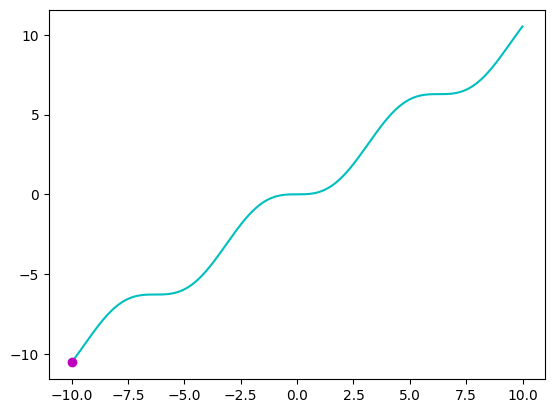

 message: Solution found.
 success: True
  status: 0
     fun: -10.54401457448588
       x: -9.999996445815212
     nit: 29
    nfev: 29



In [ ]:
def f1_3(x):
    return x - np.sin(x)

x3 = np.arange(-10, 10, 0.01)

result1_3_1 = optimize.minimize_scalar(f1_3, method='bounded', bounds=(-10, -5))

plt.plot(x3, f1_3(x3), 'c')
plt.plot(result1_3_1.x, result1_3_1.fun, "om")
plt.show()

print(result1_3_1)
print()

## Two variable functions

### $ f(x, y) = x^2 + y^2 $

There was used conjugate gradient (CG) and Nelder-Mead methods. There was indicated initial guess, equal to $ [0; 0] $ (since in graph minimum point seems to be close to this point). Both optimizations returned the same point - $ (0, 0) $. It is global minimum. CG-method is preferred, since it needed 0 iterations to find the minimum (Nelder-Mead method needed 4).

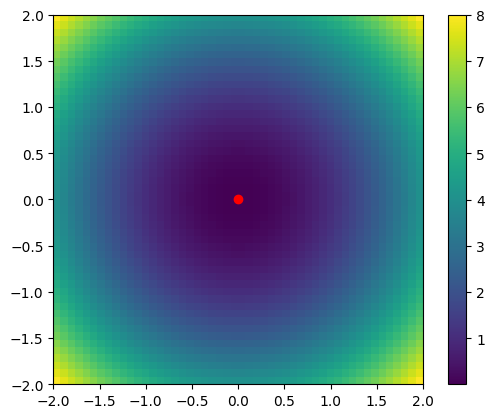

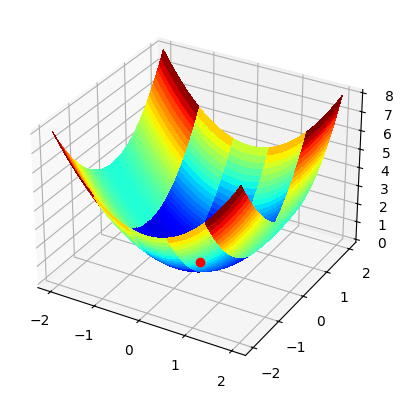

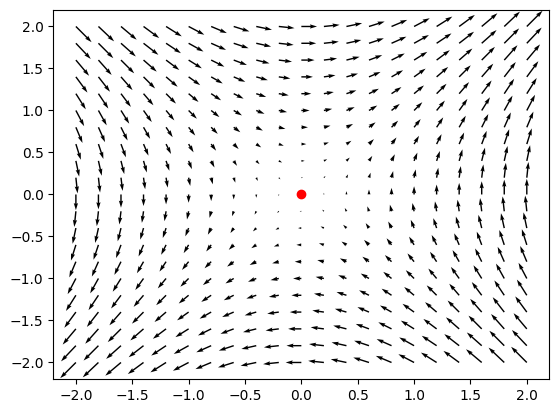

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 2.911324052194615e-15
       x: [-4.895e-08  2.270e-08]
     nit: 1
     jac: [-8.300e-08  6.030e-08]
    nfev: 9
    njev: 3

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.0
             x: [ 0.000e+00  0.000e+00]
           nit: 4
          nfev: 9
 final_simplex: (array([[ 0.000e+00,  0.000e+00],
                       [ 1.172e-05,  8.594e-05],
                       [-7.813e-05,  9.375e-05]]), array([ 0.000e+00,  7.523e-09,  1.489e-08]))


In [ ]:
def f2_1(x):
    return x[0]**2 + x[1]**2

x = np.linspace(-2,2)
y = np.linspace(-2,2)
xg, yg = np.meshgrid(x, y)

result2_1_1 = optimize.minimize(f2_1, x0=[1.5, -1], method='CG')
result2_1_2 = optimize.minimize(f2_1, x0=[0, 0], method='Nelder-Mead')

plt.figure()
plt.imshow(f2_1([xg, yg]), extent=[-2, 2, -2, 2], origin = 'upper')
plt.colorbar()
plt.plot(result2_1_1.x[0], result2_1_1.x[1], "or")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xg, yg, f2_1([xg, yg]), rstride=1, cmap=plt.cm.jet, linewidth=0, antialiased=False)
plt.plot(result2_1_1.x[0], result2_1_1.x[1], result2_1_1.fun, "or", zorder=3)
plt.show()


xx = np.arange(-2, 2.2, 0.2)
yy = np.arange(-2, 2.2, 0.2)
XX, YY = np.meshgrid(xx, yy)
dx, dy = np.gradient(f2_1([XX, YY]))

fig, ax = plt.subplots()
q = ax.quiver(xx, yy, dx, dy)
plt.plot(result2_1_1.x[0], result2_1_1.x[1], "or")
plt.show()

print(result2_1_1)
print()
print(result2_1_2)

.
### $ f(x, y) = x^2 + 100y^2 $

Minimum point cannot be obviously found on the plot, but this function's minimums can be easily found mathematically:

$ f_{3[x]}'(x, y) = 2x \qquad f_{3[y]}'(x, y) = 200y$

$ \qquad \qquad \qquad \begin{cases} 2x = 0 \\ 200y = 0 \end{cases}$

$ \qquad \qquad \qquad \begin{cases} x = 0 \\ y = 0 \end{cases}$

$ \qquad \qquad \qquad \underline{(x_0, y_0) = (0, 0)} $

$ \qquad \qquad \qquad \underline{f_3(x_0, y_0) = 0} $

$ f_{3[xx]}''(x, y) = 2 \qquad f_{3[yy]}''(x, y) = 200 \qquad f_{3[xy]}''(x, y) = 0 $

$ D = f_{3[xx]}''(x_0, y_0) × f_{3[yy]}''(x_0, y_0) - (f_{3[xy]}''(x_0, y_0))^2 = 2 × 200 - 0^2 = 400 > 0$

$ f_{3[xx]}''(x_0, y_0) = 2 > 0 $

$ D > 0, \text{ } f_{3[xx]}''(x_0, y_0) > 0  => \underline{(0, 0, 0) \text{ is minimum}} $

There was used conjugate gradient (CG) and Powell methods. There was indicated initial guess, equal to $ [0; 0] $ (as was computed before). Both optimizations returned the same point - $ (0, 0) $, which is global minimum. CG-method is preferred, since it needed 0 iterations to find the minimum (Powell method needed 1).

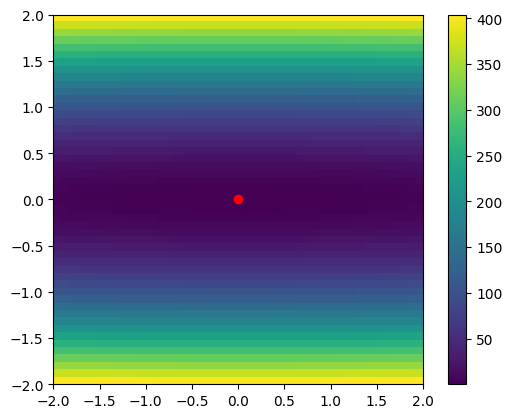

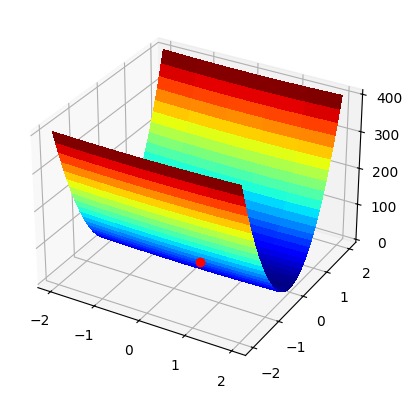

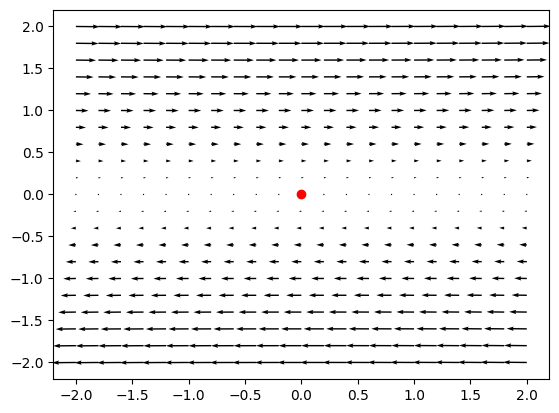

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.0
       x: [ 0.000e+00  0.000e+00]
     nit: 0
     jac: [ 1.490e-08  1.490e-06]
    nfev: 3
    njev: 1

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.0
       x: [ 0.000e+00  0.000e+00]
     nit: 1
   direc: [[ 1.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00]]
    nfev: 15


In [ ]:
def f2_2(x):
    return x[0]**2 + 100*x[1]**2

x = np.linspace(-2,2)
y = np.linspace(-2,2)

xg, yg = np.meshgrid(x, y)

result2_2_1 = optimize.minimize(f2_2, x0=[0, 0], method='CG')
result2_2_2 = optimize.minimize(f2_2, x0=[0, 0], method='Powell')

plt.figure()
plt.imshow(f2_2([xg, yg]), extent=[-2, 2, -2, 2], origin = 'upper')
plt.plot(result2_2_1.x[0], result2_2_1.x[1], "or")
plt.colorbar()
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xg, yg, f2_2([xg, yg]), rstride=1, cmap=plt.cm.jet, linewidth=0, antialiased=False)
plt.plot(result2_2_1.x[0], result2_2_1.x[1], result2_2_1.fun, "or", zorder=3)
plt.show()

xx = np.arange(-2, 2.2, 0.2)
yy = np.arange(-2, 2.2, 0.2)
XX, YY = np.meshgrid(xx, yy)
dx, dy = np.gradient(f2_2([XX, YY]))

fig, ax = plt.subplots()
q = ax.quiver(xx, yy, dx, dy)
plt.plot(result2_2_1.x[0], result2_2_1.x[1], "or")
plt.show()

print(result2_2_1)
print()
print(result2_2_2)

.
### $ f(x, y) = 100(y - x^2)^2 + (1 - x)^2 $

Minimum point cannot be obviously found on the plot, but it can be found logically. Since the function is a sum of two squares (it can be rewritten as $ f(x, y) = (10y - 10x^2)^2 + (1 - x)^2 $), minimum of this function cannot be less than 0 (sum of two squares cannot be less than zero). Then let's check, whether this function can be zero. If it is, then each square should be:

$ \begin{cases} (10y - 10x^2)^2 = 0 \\ (1 - x)^2 = 0 \end{cases} $

$ \begin{cases} 10y - 10x^2 = 0 \\ 1 - x = 0 \end{cases} $

$ => \underline{x = 1} $

$ => 10y - 10 = 0 => \underline{y = 1} $

$ \underline{f_3(1, 1) = 0} $

Therefore, there is global minimum in point $ (1, 1, 0) $.

There was used conjugate gradient (CG), BFGS, Powell, and Nedler-Mead methods. There was indicated initial guess, equal to $ [1; 1] $ (as was computed before). All the optimizations returned the same point - $ (1, 1) $, which is global minimum. CG and BFGS methods are the best, since it needed 0 iterations to find the minimum. Powell method needed 1, Nelder-Mead - 24 (it is the worst one).

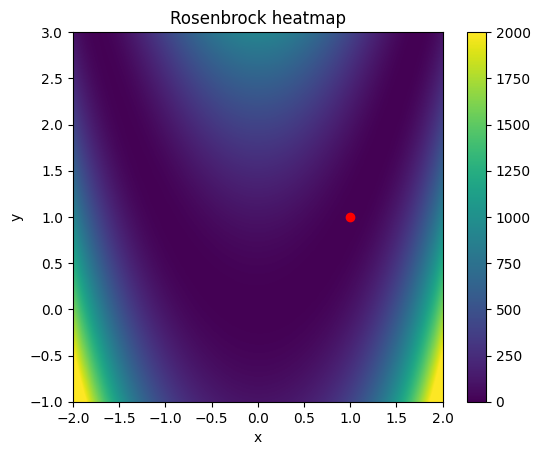

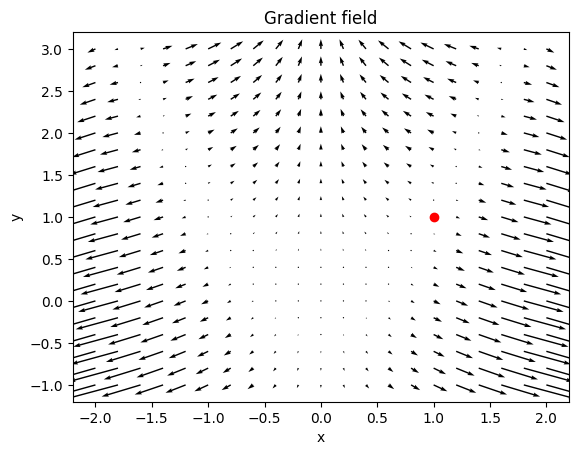

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.0
       x: [ 1.000e+00  1.000e+00]
     nit: 0
     jac: [ 5.975e-06  1.490e-06]
    nfev: 3
    njev: 1 

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.0
             x: [ 1.000e+00  1.000e+00]
           nit: 24
          nfev: 49
 final_simplex: (array([[ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  9.999e-01]]), array([ 0.000e+00,  2.815e-09,  4.426e-09])) 



In [ ]:
def f2_3(v):
    x, y = v
    return 100*((y - x**2)**2) + (1 - x)**2

# --- grid (keep your current window) ---
x = np.linspace(-2, 2, 401)
y = np.linspace(-1, 3, 401)
xg, yg = np.meshgrid(x, y)

Z = f2_3([xg, yg])

result_cg     = optimize.minimize(f2_3, x0=[1, 1], method='CG')
result_nm     = optimize.minimize(f2_3, x0=[1, 1], method='Nelder-Mead')

plt.figure()

Z_vis = np.clip(Z, None, 2000)
plt.imshow(Z_vis, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
plt.colorbar()
plt.plot(result_cg.x[0], result_cg.x[1], "or")  # same marker call
plt.title("Rosenbrock heatmap")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

xx = np.arange(-2,  2.1, 0.2)
yy = np.arange(-1,  3.1, 0.2)
XX, YY = np.meshgrid(xx, yy)
ZZ = f2_3([XX, YY])

dZZ_dy, dZZ_dx = np.gradient(ZZ, yy, xx)

fig, ax = plt.subplots()
q = ax.quiver(XX, YY, dZZ_dx, dZZ_dy)  # same quiver (no normalization)
ax.plot(result_cg.x[0], result_cg.x[1], "or")
ax.set_title("Gradient field")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.show()

# --- same prints ---
print(result_cg, "\n")
print(result_nm, "\n")


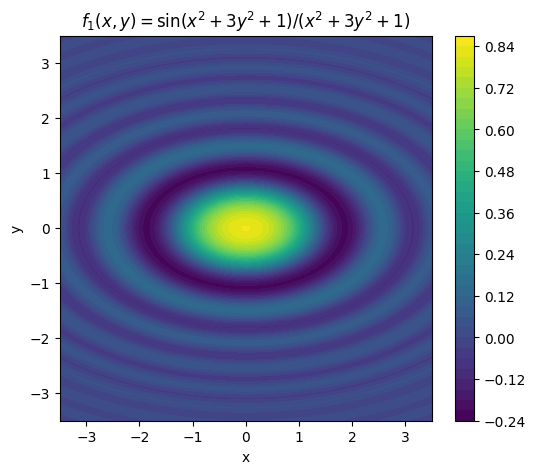

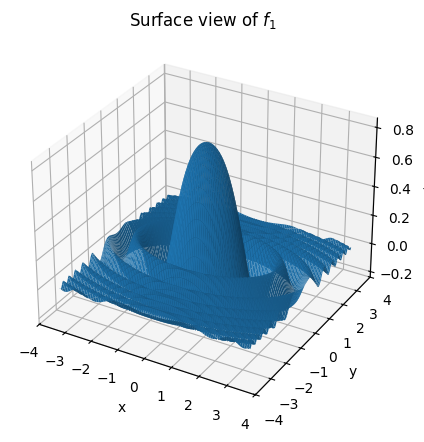

In [ ]:
def f1_xy(X, Y):
    r = X**2 + 3*Y**2 + 1
    return np.sin(r) / r

x = np.linspace(-3.5, 3.5, 400)
y = np.linspace(-3.5, 3.5, 400)
X, Y = np.meshgrid(x, y, indexing="xy")
Z = f1_xy(X, Y)

plt.figure(figsize=(6,5))
cs = plt.contourf(X, Y, Z, levels=40)
plt.colorbar(cs)
plt.title(r"$f_1(x,y)=\sin(x^2+3y^2+1)/(x^2+3y^2+1)$")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, rstride=4, cstride=4, linewidth=0, antialiased=True)
ax.set_title("Surface view of $f_1$")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("f1")
plt.show()


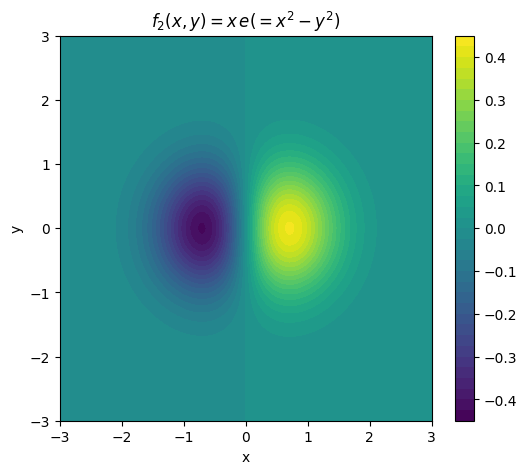

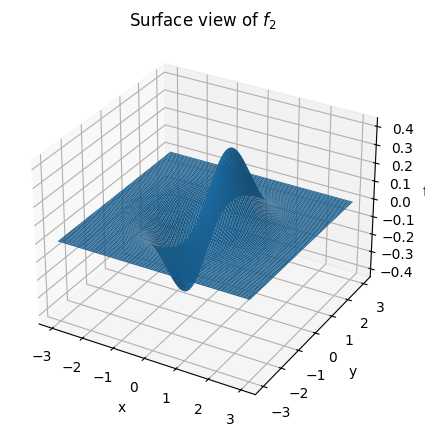

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def f2_xy(X, Y):
    R2 = X**2 + Y**2
    return X * np.exp(-R2)

x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y, indexing="xy")
Z = f2_xy(X, Y)

plt.figure(figsize=(6,5))
cs = plt.contourf(X, Y, Z, levels=40)
plt.colorbar(cs)
plt.title(r"$f_2(x,y)=x\,e{(=x^2-y^2)}$")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, rstride=4, cstride=4, linewidth=0, antialiased=True)
ax.set_title("Surface view of $f_2$")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("f2")
plt.show()
